# Heating-Oil-Seasonality — a quantitative teardown 🔬
### The Bonferroni-12 month table · autumn-build vs winter-draw Welch splits · a seasonal timer race with costs · the UHN-vs-splice paired gap · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Rule_of_thumb%3F: Busted](https://img.shields.io/badge/Rule_of_thumb%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **HO=F builds through autumn and holds through the winter draw** — has a genuine physical anchor (EIA weekly distillate stocks) but no *a priori* guarantee the futures price obeys it: a storable commodity can price a well-known seasonal demand shock in advance, and the front-month chain already contains real roll friction. The job here is to test both stages honestly and then ask whether anyone could have banked it.

> ⚠️ **Data note.** HO=F daily raw OHLC (2000-09 → 2026-06, 309 monthly obs) + UHN adjusted closes (2008-04 → 2018-09, its whole trading life) + ^IRX, yfinance, cached. HO=F is a **spliced continuous chain, not back-adjusted** — the roll-day price jump *is* the term-structure cost/gain a real futures holder pays, by construction. No survivorship on the Signal axis (a futures chain, not a basket); **UHN's 2018 wind-down is named on the third axis**. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `5e77c79ac501` / `f140d3086a31` / `97d049b701d7`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from heating_oil_seasonality import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    HO, UHN, IRX = data.load_real()
    HO_RET = data.monthly_returns(HO["Close"], asof=data.AS_OF)
    TBILL = data.monthly_cash_rate(IRX["Close"], HO_RET.index)
else:
    HO = UHN = IRX = HO_RET = TBILL = None
print("real cache present:", HAVE_REAL, "| HO=F monthly obs:", (0 if HO_RET is None else len(HO_RET)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2000-10-31', 'end': '2026-06-30', 'n_months': 309, 'months': {'Jan': (2.49, 1.25, 26), 'Feb': (3.26, 1.39, 26), 'Mar': (1.22, 0.36, 26), 'Apr': (1.65, 0.77, 26), 'May': (-0.26, -0.12, 26), 'Jun': (3.14, 2.33, 26), 'Jul': (1.08, 0.64, 25), 'Aug': (2.23, 1.49, 25), 'Sep': (0.13, 0.07, 25), 'Oct': (-0.78, -0.4, 26), 'Nov': (-2.12, -1.02, 26), 'Dec': (-0.41, -0.21, 26)}, 'bonferroni_t': 3.0, 'autumn_mean': -0.94, 'autumn_n': 77, 'autumn_t': -1.71, 'winter_mean': 1.78, 'winter_n': 78, 'winter_t': 0.18, 'heat_mean': 0.43, 'heat_n': 155, 'heat_t': -0.89, 'off_mean': 1.51, 'off_n': 154, 'bh_cagr': 5.06, 'bh_sharpe': 0.27, 'bh_dd': -81, 'timer_gross_cagr': 0.29, 'timer_gross_sharpe': 0.07, 'timer_gross_dd': -72, 'timer_net5_cagr': 0.19, 'timer_net5_sharpe': 0.06, 'timer_net5_dd': -72, 'timer_net10_cagr': 0.08, 'timer_net10_sharpe': 0.06, 'timer_net10_dd': -73, 'uhn_seasons': [('2008-2009', -60.72, -58.81, -1.9), ('2009-2010', 4.31, 13.81, -9.5), ('2010-2011', 42.58, 46.7, -4.12), ('2011-2012', 4.35, 4.73, -0.38), ('2012-2013', -6.66, -6.24, -0.42), ('2013-2014', -0.35, -1.87, 1.52), ('2014-2015', -23.18, -17.8, -5.38), ('2015-2016', -43.38, -37.19, -6.19), ('2016-2017', 7.57, 14.93, -7.36), ('2017-2018', 10.79, 8.88, 1.91)], 'uhn_gap_mean': -3.18, 'uhn_gap_t': -2.58, 'uhn_gap_n': 10, 'uhn_start': '2008-04-10', 'uhn_end': '2018-09-11', 'syn_null_mean': -0.19, 'syn_null_sd': 1.01, 'syn_null_fire': 0, 'syn_planted_t': 3.61, 'fp_ho': '5e77c79ac501', 'fp_uhn': 'f140d3086a31', 'fp_irx': '97d049b701d7'}


real cache present: True | HO=F monthly obs: 309


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | autumn-build **-0.94%** (n=77) vs off-season **+1.51%** (n=154): Welch **t = -1.71** (wrong sign); winter-draw t = 0.18; pooled heating-window t = -0.89; **no month clears Bonferroni-12** (|t| ≥ ~3.0) |
| **Tradability** | `MIRAGE` | seasonal timer Sharpe **0.07** gross vs buy-and-hold **0.27**; UHN vs splice gap **-3.18%/season** (t = -2.58, n=10); UHN wound down 2018-09-11 |
| **Rule of thumb?** | `BUSTED` | autumn half runs backward, winter half is noise, the retail vehicle no longer exists |

> 💡 In plain words: the physical demand story is true; the price story the folklore promises on top of it is not there, and where it's closest to showing up (autumn) it shows up **backward**.

## 1 · The claim, steelmanned

Let $r_t$ be HO=F's monthly return and define three calendar sets: $\text{Autumn} = \{Sep, Oct, Nov\}$, $\text{Winter} = \{Dec, Jan, Feb\}$, $\text{Off} = \{Mar,\dots,Aug\}$. The claims:

- **H₁ (autumn build).** $E[r_t \mid t \in \text{Autumn}] > E[r_t \mid t \in \text{Off}]$ — the market prices the coming winter ahead of time.
- **H₂ (winter draw).** $E[r_t \mid t \in \text{Winter}] > E[r_t \mid t \in \text{Off}]$ — the price holds or extends as physical stocks fall.
- **H₃ (per-month).** At least one calendar month shows a real, Bonferroni-robust one-sample effect — a sanity check that doesn't presume the exact window.
- **H₄ (capture).** A calendar-timed long position (Sep–Feb, cash otherwise) beats buy-and-hold net of costs, and a real investable vehicle (UHN) captures it.

We find **H₁ rejected — and wrong-signed** (autumn *t* = -1.71), **H₂ not supported** (winter *t* = 0.18), **H₃ rejected** (no month clears |t| ≥ 3.0), **H₄ rejected** (timer Sharpe << buy-and-hold; UHN loses to the splice; the vehicle no longer exists).

## 2 · So what? — inference design

Calendar months are **non-overlapping** observations, so **Welch's *t*** (unequal variances) is the planned primary for every two-group split — autumn-build vs off-season, winter-draw vs off-season, and the pooled heating window vs off-season. The per-month table tests **12 hypotheses at once** (one per calendar month), so it carries a **Bonferroni correction**: at α = 0.05, the per-test threshold is α/12 ≈ 0.0042, i.e. |*t*| ≥ ~3.0 at *n* ≈ 25 — not the everyday |*t*| ≥ 2 bar. The UHN-vs-splice gap is a **paired, one-sample** *t* across 10 non-overlapping heating seasons — reported honestly as a small-sample number, never inflated.

## 3 · How we'd know — the protocol

- **Tape.** HO=F daily raw OHLC 2000-10-31 → 2026-06-30, resampled to **309 complete calendar months** (in-progress month dropped, hole-free grid asserted). As-of 2026-06-30.
- **Headline.** Per-month one-sample *t* + Bonferroni-12 bar; Welch *t* for autumn-build / winter-draw / pooled-heating vs off-season.
- **Execution (tradability).** Long HO=F Sep–Feb, T-bill (^IRX/12) otherwise, one fixed calendar rule (zero look-ahead by construction); 2 switches/yr; one-way cost × NAV per switch (0/5/10 bps); Sharpe = excess of T-bill on both legs.
- **Cross-check.** UHN (retail ETF, real front-month holder) vs the HO=F splice, paired per heating season, over UHN's whole 2008–2018 life.
- **Control.** i.i.d. synthetic monthly world, planted heating-season premium knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The Bonferroni month table

Twelve one-sample *t*-tests (mean vs 0), one per calendar month — and twelve chances to find a false positive if we used the everyday |*t*| ≥ 2 bar.

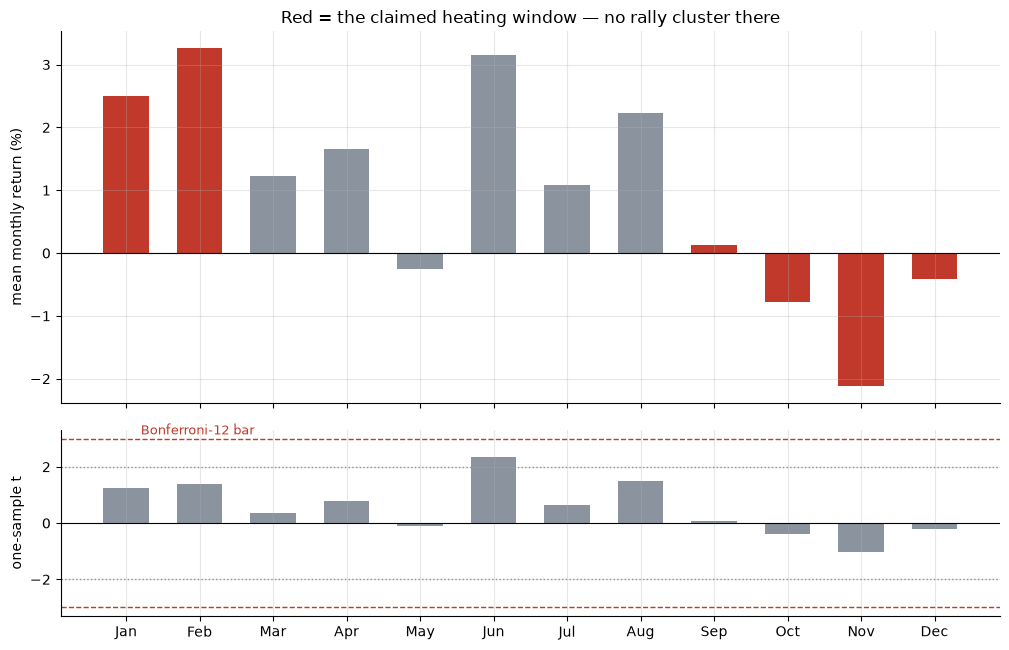

{'Jan': (np.float64(2.49), np.float64(1.25)), 'Feb': (np.float64(3.26), np.float64(1.39)), 'Mar': (np.float64(1.22), np.float64(0.36)), 'Apr': (np.float64(1.65), np.float64(0.77)), 'May': (np.float64(-0.26), np.float64(-0.12)), 'Jun': (np.float64(3.14), np.float64(2.33)), 'Jul': (np.float64(1.08), np.float64(0.64)), 'Aug': (np.float64(2.23), np.float64(1.49)), 'Sep': (np.float64(0.13), np.float64(0.07)), 'Oct': (np.float64(-0.78), np.float64(-0.4)), 'Nov': (np.float64(-2.12), np.float64(-1.02)), 'Dec': (np.float64(-0.41), np.float64(-0.21))}


In [2]:
if HAVE_REAL:
    ms = st.month_stats(HO_RET)
    means = [ms.loc[i,'mean']*100 for i in range(1,13)]
    ts = [ms.loc[i,'t'] for i in range(1,13)]
else:
    means = [R['months'][m][0] for m in ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']]
    ts = [R['months'][m][1] for m in ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']]
names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
heat = {'Sep','Oct','Nov','Dec','Jan','Feb'}
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10.2, 6.6), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
a1.bar(names, means, color=[RED if n in heat else GREY for n in names], width=.62)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean monthly return (%)')
a1.set_title('Red = the claimed heating window — no rally cluster there')
a2.bar(names, ts, color=[RED if abs(t)>=R['bonferroni_t'] else GREY for t in ts], width=.62)
a2.axhline(0, c='k', lw=.8)
a2.axhline(-R['bonferroni_t'], ls='--', c=RED, lw=1)
a2.axhline(R['bonferroni_t'], ls='--', c=RED, lw=1)
a2.axhline(-2, ls=':', c=GREY, lw=1); a2.axhline(2, ls=':', c=GREY, lw=1)
a2.annotate('Bonferroni-12 bar', (0.2, R['bonferroni_t']+.15), color=RED, fontsize=9)
a2.set_ylabel('one-sample t'); plt.tight_layout(); plt.show()
print({n: (round(m,2), round(t,2)) for n, m, t in zip(names, means, ts)})

No bar in the bottom panel reaches the red dashed Bonferroni line. The only month past the *lenient*, uncorrected |*t*| ≥ 2 dotted line is **June** (t = 2.33) — driving season, not heating season — and it still falls short of Bonferroni. **H₃ rejected.**

### 4b · Autumn-build vs winter-draw — the two stages, Welch-tested separately

Blending Sep–Feb into one window would hide exactly the disagreement this study finds — so each stage is tested on its own, against the same off-season control.

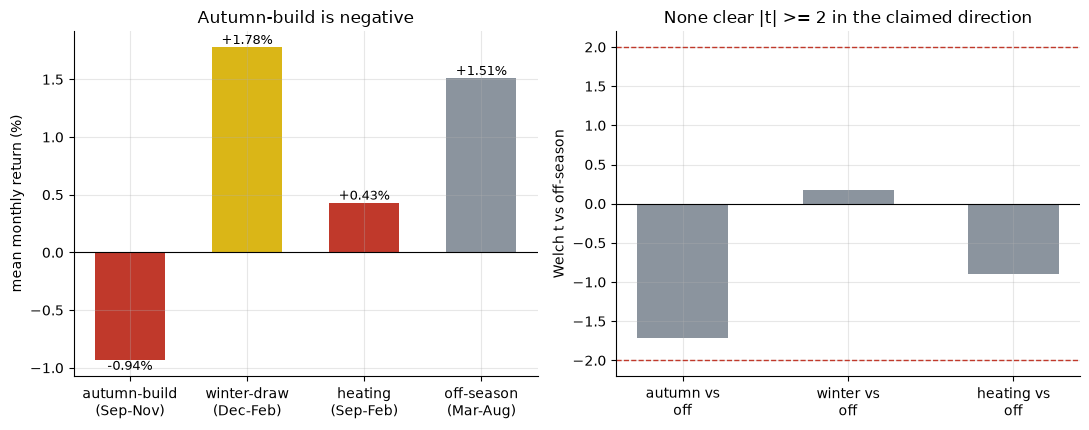

autumn t=-1.71  winter t=0.18  pooled-heating t=-0.89


In [3]:
if HAVE_REAL:
    ab = st.group_welch(HO_RET, data.AUTUMN_BUILD_MONTHS, data.OFF_SEASON_MONTHS)
    wd = st.group_welch(HO_RET, data.WINTER_DRAW_MONTHS, data.OFF_SEASON_MONTHS)
    hw = st.group_welch(HO_RET, data.HEATING_MONTHS, data.OFF_SEASON_MONTHS)
    a_m, a_t = ab['mean_a']*100, ab['t']
    w_m, w_t = wd['mean_a']*100, wd['t']
    h_m, h_t = hw['mean_a']*100, hw['t']
    o_m = ab['mean_b']*100
else:
    a_m, a_t = R['autumn_mean'], R['autumn_t']
    w_m, w_t = R['winter_mean'], R['winter_t']
    h_m, h_t = R['heat_mean'], R['heat_t']
    o_m = R['off_mean']
fig, (b1, b2) = plt.subplots(1, 2, figsize=(11.0, 4.4))
labels = ['autumn-build\n(Sep-Nov)', 'winter-draw\n(Dec-Feb)', 'heating\n(Sep-Feb)', 'off-season\n(Mar-Aug)']
means = [a_m, w_m, h_m, o_m]
b1.bar(labels, means, color=[RED, AMBER, RED, GREY], width=.6)
for i, v in enumerate(means): b1.annotate(f'{v:+.2f}%', (i, v), ha='center', va='top' if v<0 else 'bottom', fontsize=9)
b1.axhline(0, c='k', lw=.8); b1.set_ylabel('mean monthly return (%)')
b1.set_title('Autumn-build is negative')
ts = [a_t, w_t, h_t]
b2.bar(['autumn vs\noff', 'winter vs\noff', 'heating vs\noff'], ts,
       color=[RED if abs(t)>=2 else GREY for t in ts], width=.55)
b2.axhline(-2, ls='--', c=RED, lw=1); b2.axhline(2, ls='--', c=RED, lw=1)
b2.axhline(0, c='k', lw=.8); b2.set_ylabel('Welch t vs off-season')
b2.set_title('None clear |t| >= 2 in the claimed direction')
plt.tight_layout(); plt.show()
print(f'autumn t={a_t:.2f}  winter t={w_t:.2f}  pooled-heating t={h_t:.2f}')

> 💡 In plain words: autumn-build is **-0.94%** vs off-season's **+1.51%** — Welch *t* = **-1.71**, the single closest-to-significant result in the whole study, and it says the opposite of the folklore. Winter-draw (+1.78%, t = 0.18) is statistically indistinguishable from an ordinary month. Pooled, the heating window actually **trails** the off-season (t = -0.89). **H₁ rejected and wrong-signed; H₂ not supported.**

### 4c · Tradability — the timer, gross and net of costs

Long HO=F on a fixed Sep 1 → end-Feb calendar rule (zero look-ahead by construction), the 13-week T-bill otherwise; Sharpe excess-of-cash on both legs; one-way cost × NAV at each of 2 switches/year.

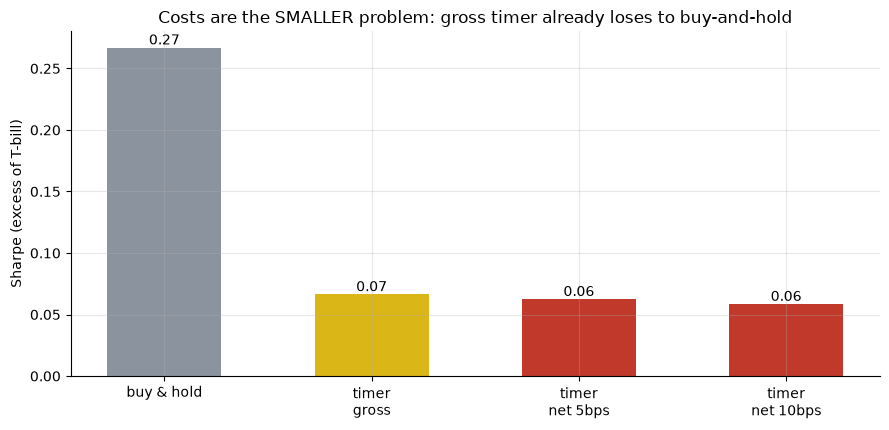

buy&hold 0.27  timer gross/net5/net10 = 0.07, 0.06, 0.06


In [4]:
if HAVE_REAL:
    bh = st.summary(st.buy_hold(HO_RET), rf=TBILL)
    rows = [st.summary(st.seasonal_timer(HO_RET, TBILL, data.HEATING_MONTHS, cost_bps=cb), rf=TBILL)
            for cb in (0.0, 5.0, 10.0)]
    bh_s, sharpes = bh['sharpe'], [r['sharpe'] for r in rows]
else:
    bh_s = R['bh_sharpe']
    sharpes = [R['timer_gross_sharpe'], R['timer_net5_sharpe'], R['timer_net10_sharpe']]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
labels = ['buy & hold', 'timer\ngross', 'timer\nnet 5bps', 'timer\nnet 10bps']
vals = [bh_s] + sharpes
ax.bar(labels, vals, color=[GREY, AMBER, RED, RED], width=.55)
for i, v in enumerate(vals): ax.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom')
ax.set_ylabel('Sharpe (excess of T-bill)')
ax.set_title('Costs are the SMALLER problem: gross timer already loses to buy-and-hold')
plt.tight_layout(); plt.show()
print(f'buy&hold {bh_s:.2f}  timer gross/net5/net10 = ' + ', '.join(f'{v:.2f}' for v in sharpes))

> 💡 In plain words: buy-and-hold's Sharpe (0.27) is roughly **four times** the gross timer's (0.07) — before a single basis point of cost. Charging costs barely moves the number (0.06 at 5bps, 0.06 at 10bps) because the strategy is broken by construction: it sits in cash through June, HO=F's best month (+3.14%), on the theory that summer months don't matter. **H₄'s timer half rejected.**

### 4d · The real vehicle — UHN vs the HO=F splice, paired per season

UHN held front-month HO=F futures directly for retail, 2008-04-10 → 2018-09-11 (then wound down — **it does not exist today**). Paired per heating season (Aug 31 close → next Feb 28 close): `gap = UHN return − HO=F splice return`.

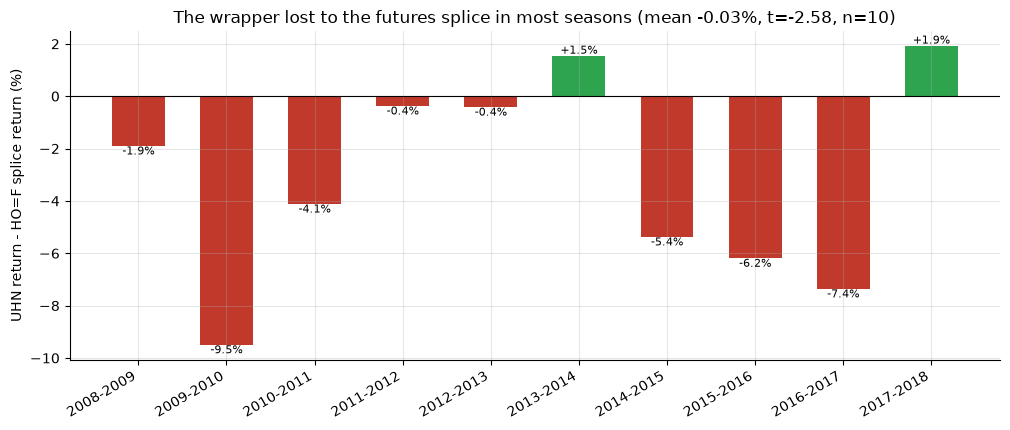

mean gap -0.03%/season  t=-2.58  n=10


In [5]:
if HAVE_REAL:
    gap_df = st.uhn_vs_splice(UHN['Close'], HO['Close'], 2008, 2018)
    gs = st.uhn_gap_stats(gap_df)
    seasons = list(gap_df['season']); gaps = list(gap_df['gap']*100)
    gmean, gt, gn = gs['mean_gap'], gs['t'], gs['n']
else:
    seasons = [s for s, *_ in R['uhn_seasons']]
    gaps = [g for *_, g in R['uhn_seasons']]
    gmean, gt, gn = R['uhn_gap_mean'], R['uhn_gap_t'], R['uhn_gap_n']
fig, ax = plt.subplots(figsize=(10.2, 4.4))
ax.bar(seasons, gaps, color=[RED if g<0 else GREEN for g in gaps], width=.6)
for i, v in enumerate(gaps): ax.annotate(f'{v:+.1f}%', (i, v), ha='center',
    va='top' if v<0 else 'bottom', fontsize=8, rotation=0)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('UHN return - HO=F splice return (%)')
ax.set_title(f'The wrapper lost to the futures splice in most seasons (mean {gmean:+.2f}%, t={gt:.2f}, n={gn})')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()
print(f'mean gap {gmean:+.2f}%/season  t={gt:.2f}  n={gn}')

> 💡 In plain words: UHN trailed the raw futures splice in **8 of 10** heating seasons — a mean gap of **-3.18%** (*t* = -2.58). At *n* = 10 non-overlapping seasons this is **not certifiable on its own** — said out loud — but the sign is consistent and it never helps the claim: the wrapper's expense ratio and tracking slippage stack a *second* real drag on top of whatever roll cost HO=F's splice already embeds. And this is history, not a live option: **the fund no longer exists.**

### 4e · Faithful-engine & power control — we know the truth here

i.i.d. monthly synthetic world, TUNABLE planted heating-season premium spread over Sep–Feb. The null (seasonal = 0) is checked over **20 seeds** — never a single stream.

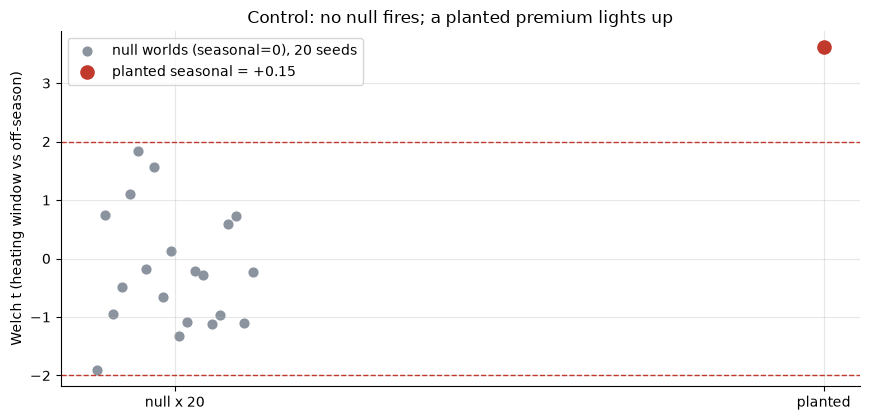

null: mean t = -0.19 (sd 1.01), |t|>=2 in 0/20 seeds  |  planted t = +3.61


In [6]:
null_ts = []
for s_ in range(20):
    world = data.synthetic_world(seasonal=0.0, seed=1000 + s_)
    null_ts.append(st.synthetic_detect(world, data.HEATING_MONTHS, data.OFF_SEASON_MONTHS))
null_ts = np.asarray(null_ts)
planted = data.synthetic_world(seasonal=0.15, seed=650)
planted_t = st.synthetic_detect(planted, data.HEATING_MONTHS, data.OFF_SEASON_MONTHS)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (seasonal=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5, label='planted seasonal = +0.15')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t (heating window vs off-season)')
ax.set_title('Control: no null fires; a planted premium lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = -0.19 (sd 1.01) and **never** crosses the bar; a planted premium comparable in size to a real seasonal claim reads t = 3.61. The machinery is unbiased — the real-tape's failure to fire is the genuine article, not a broken test. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — autumn-build **-0.94%** vs off-season **+1.51%**: Welch t = **-1.71** (wrong sign); winter-draw t = 0.18; pooled heating-window t = -0.89; no month clears the Bonferroni-12 bar (|t| ≥ ~3.0).
- **Tradability `MIRAGE`** — seasonal timer Sharpe 0.07 gross (barely moves net of costs) vs buy-and-hold's 0.27; UHN lagged the futures splice by -3.18%/season across 10 seasons before it was wound down in 2018-09-11 — the retail vehicle no longer exists.
- **"Heating oil rallies into winter"? `BUSTED`** — the physical demand story is real; the price story built on top of it is not, and the closest it comes to real is running backward.

## 6 · Going further

- **The theory-of-storage angle.** Fama-French (1987) on storable-commodity futures: a market that *knows* a demand shock is coming can price it well before the shock's own calendar window — the seasonal, if it exists, may live upstream of September, not inside the Sep–Feb window folklore names. A term-structure study (does the HO futures *curve* itself carry a seasonal shape, independent of spot returns?) is the natural sequel.
- **Dedup map:** [227-natgas-winter](../../227-natgas-winter/) (the parallel, also wrong-signed, winter-demand claim for natural gas), [639-gasoline-rvp-seasonality](../../639-gasoline-rvp-seasonality/) (a *statutory* spring/autumn calendar — real on the spread, mirage on the roll), [306-crack-spread](../../306-crack-spread/) (does the crack level predict refiners? — a different mechanism), [226-crude-seasonality](../../226-crude-seasonality/) (WTI's spring seasonal — a different commodity and season).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*